# Data Preprocessing and Augmentation

**Goal:** Prepare training data for model training

**Contents:**
1. Load training dataset
2. Define augmentation
3. Create DataLoader
4. Test Pipeline


## 1. Import Libraries

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import json
from pathlib import Path
import time

# Constants - Image size configuration
IMG_SIZE = (224, 224)  # Standard input size for most CNN models
BATCH_SIZE = 32  # Batch size for training


# 2. Load Dataset
# Load train, validation, and test CSV files

In [39]:
train_df = pd.read_csv("../../datasets/idnet/document_type_classification/data/train_dataset.csv")
val_df = pd.read_csv("../../datasets/idnet/document_type_classification/data/val_dataset.csv")
test_df = pd.read_csv("../../datasets/idnet/document_type_classification/data/test_dataset.csv")

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Display sample rows
print(train_df.head())

Train samples: 1470
Validation samples: 315
Test samples: 315
                                          image_path   document_type
0  /Users/roy-siftt/final-project/datasets/idnet/...         id_card
1  /Users/roy-siftt/final-project/datasets/idnet/...  driver_license
2  /Users/roy-siftt/final-project/datasets/idnet/...        passport
3  /Users/roy-siftt/final-project/datasets/idnet/...        passport
4  /Users/roy-siftt/final-project/datasets/idnet/...         id_card


# 3. Visualize Class Distribution

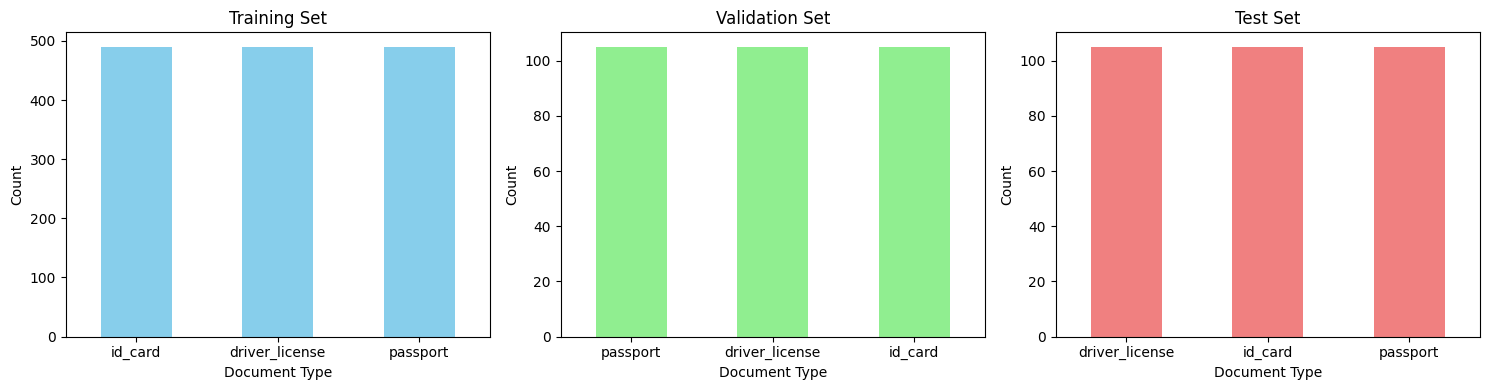

Class Distribution:

Train Set:
  id_card: 490 (33.3%)
  driver_license: 490 (33.3%)
  passport: 490 (33.3%)

Validation Set:
  passport: 105 (33.3%)
  driver_license: 105 (33.3%)
  id_card: 105 (33.3%)

Test Set:
  driver_license: 105 (33.3%)
  id_card: 105 (33.3%)
  passport: 105 (33.3%)

CLASS DISTRIBUTION PERCENTAGES (for bias analysis)

                 Train (%)  Validation (%)  Test (%)
document_type                                      
driver_license      33.33           33.33     33.33
id_card             33.33           33.33     33.33
passport            33.33           33.33     33.33

✓ Dataset is balanced


In [40]:
# Class distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_dist = train_df['document_type'].value_counts()
val_dist = val_df['document_type'].value_counts()
test_dist = test_df['document_type'].value_counts()

train_dist.plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Training Set')
axes[0].set_xlabel('Document Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

val_dist.plot(kind='bar', color='lightgreen', ax=axes[1])
axes[1].set_title('Validation Set')
axes[1].set_xlabel('Document Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

test_dist.plot(kind='bar', color='lightcoral', ax=axes[2])
axes[2].set_title('Test Set')
axes[2].set_xlabel('Document Type')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print statistics with percentages
print("Class Distribution:")
print("\nTrain Set:")
for cls, count in train_dist.items():
    print(f"  {cls}: {count} ({count/len(train_df)*100:.1f}%)")
print("\nValidation Set:")
for cls, count in val_dist.items():
    print(f"  {cls}: {count} ({count/len(val_df)*100:.1f}%)")
print("\nTest Set:")
for cls, count in test_dist.items():
    print(f"  {cls}: {count} ({count/len(test_df)*100:.1f}%)")

# Display percentage distribution table for bias analysis
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION PERCENTAGES (for bias analysis)")
print("=" * 60)
train_pct = (train_df['document_type'].value_counts(normalize=True) * 100).round(2)
val_pct = (val_df['document_type'].value_counts(normalize=True) * 100).round(2)
test_pct = (test_df['document_type'].value_counts(normalize=True) * 100).round(2)

dist_df = pd.DataFrame({
    'Train (%)': train_pct,
    'Validation (%)': val_pct,
    'Test (%)': test_pct
}).fillna(0)
print("\n", dist_df)
print("\n✓ Dataset is balanced" if (dist_df.max(axis=1) - dist_df.min(axis=1)).max() < 5 else 
      "\n⚠️ Dataset shows some class imbalance - consider using weighted sampling")


# 4. Define Augmentation Pipeline
# Data augmentations for training and resizing for validation/test

In [41]:
# Normalization values (ImageNet - standard for pretrained models)
# If using custom model, consider computing from your dataset
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),  # Using constant for consistency
    # RandomHorizontalFlip removed - not suitable for documents (text would be reversed)
    transforms.RandomRotation(degrees=10),  # Small rotations to handle slight misalignments
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Small translations
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),  # Occasionally sharpen
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),  # Critical for training!
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),  # Using constant for consistency
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),  # Same normalization for consistency
])

# 5. Define Custom Dataset Class

In [43]:
class DocumentDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.classes = sorted(self.df['document_type'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        label = self.df.iloc[idx]['document_type']
        
        # Error handling for corrupted or missing images
        max_retries = 3
        retry_count = 0
        
        while retry_count < max_retries:
            try:
                image = Image.open(img_path).convert('RGB')
                break  # Success, exit retry loop
            except Exception as e:
                retry_count += 1
                if retry_count < max_retries:
                    # Try next image (with wrap-around)
                    idx = (idx + 1) % len(self.df)
                    img_path = self.df.iloc[idx]['image_path']
                    label = self.df.iloc[idx]['document_type']
                else:
                    # After max retries, raise the error or use a fallback
                    print(f"Error: Failed to load image after {max_retries} attempts. Last path: {img_path}, Error: {e}")
                    raise RuntimeError(f"Cannot load image: {img_path}. Error: {e}")
        
        if self.transform:
            image = self.transform(image)
        
        label = self.class_to_idx[label]
        return image, label

# 6. Create Datasets and DataLoaders

In [44]:
train_dataset = DocumentDataset(train_df, train_transforms)
val_dataset = DocumentDataset(val_df, val_transforms)
test_dataset = DocumentDataset(test_df, val_transforms)

# DataLoader settings optimized for Jupyter notebooks
# Note: num_workers=0 is required in notebooks due to multiprocessing limitations
# For production/training scripts, you can use num_workers > 0
use_pin_memory = torch.cuda.is_available()  # Only use pin_memory with CUDA (not MPS)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE,  # Using constant
    shuffle=True,
    num_workers=0,  # Required for notebooks (multiprocessing doesn't work with custom classes)
    pin_memory=use_pin_memory,  # Only for CUDA devices
    drop_last=True,  # Consistent batch sizes for batch normalization
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE,  # Using constant
    shuffle=False,  # No shuffle for validation
    num_workers=0,
    pin_memory=use_pin_memory
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE,  # Using constant
    shuffle=False,
    num_workers=0,
    pin_memory=use_pin_memory
)

print(f"Train batches: {len(train_loader)} (with drop_last)")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"\nDataLoader settings:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  num_workers: 0 (required for notebooks)")
print(f"  pin_memory: {use_pin_memory} ({'CUDA' if use_pin_memory else 'disabled for MPS/CPU'})")
print(f"  drop_last: True (train only)")

Train batches: 45 (with drop_last)
Validation batches: 10
Test batches: 10

DataLoader settings:
  Batch size: 32
  num_workers: 0 (required for notebooks)
  pin_memory: False (disabled for MPS/CPU)
  drop_last: True (train only)


# 7. Test the Pipeline
# Visualize a few samples from the training DataLoader

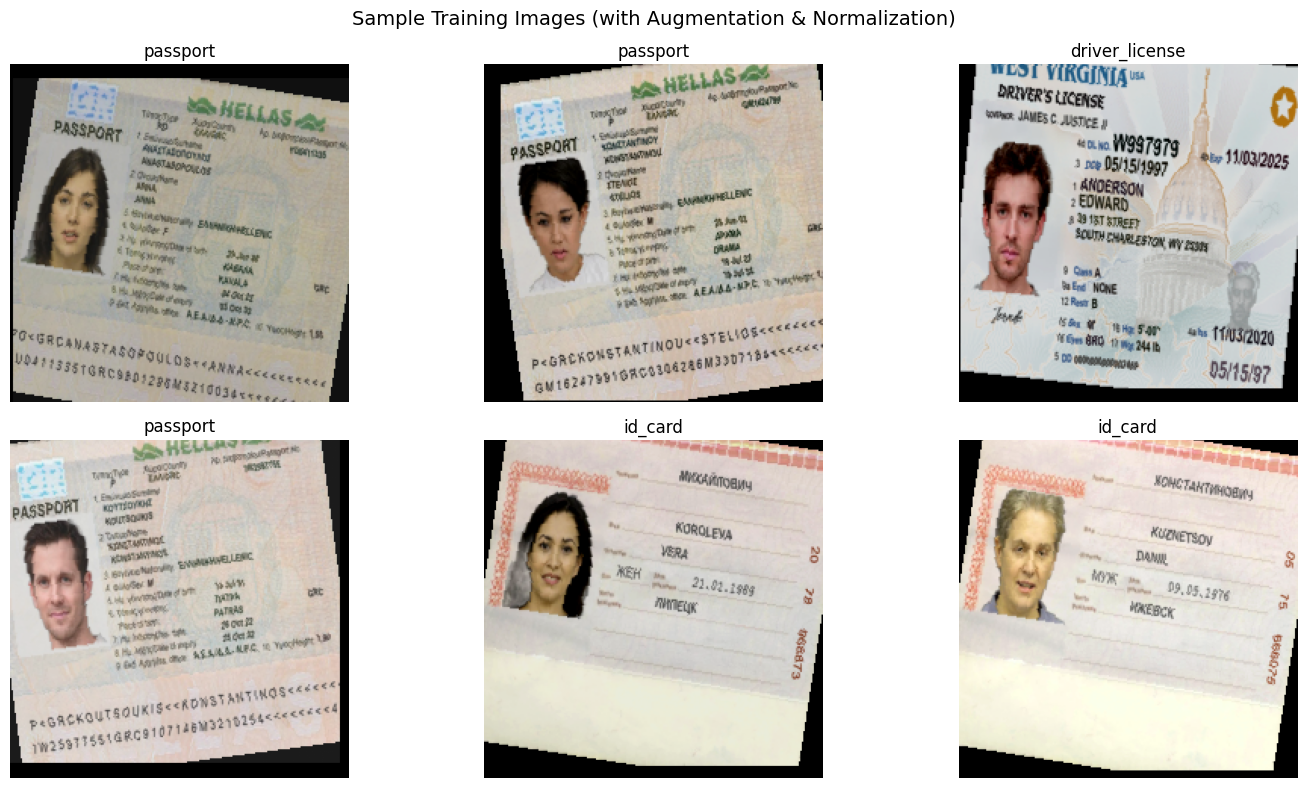


Batch Statistics:
  Batch shape: torch.Size([32, 3, 224, 224])
  Image dtype: torch.float32
  Pixel value range (after normalization): [-2.118, 2.640]
  Labels in batch: ['passport', 'passport', 'driver_license', 'passport', 'id_card', 'id_card']


In [45]:
# Visualize samples with denormalization for display
images, labels = next(iter(train_loader))

# Denormalize for visualization (images are normalized, so we reverse it)
def denormalize(tensor, mean=MEAN, std=STD):
    """Denormalize a tensor image for visualization"""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clamp_(0, 1)

plt.figure(figsize=(15, 8))
for i in range(6):
    img = images[i].clone()
    img = denormalize(img)  # Denormalize for display
    img = img.permute(1, 2, 0)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i]], fontsize=12)
    plt.axis('off')
plt.suptitle('Sample Training Images (with Augmentation & Normalization)', fontsize=14)
plt.tight_layout()
plt.show()

# Display batch statistics
print(f"\nBatch Statistics:")
print(f"  Batch shape: {images.shape}")
print(f"  Image dtype: {images.dtype}")
print(f"  Pixel value range (after normalization): [{images.min():.3f}, {images.max():.3f}]")
print(f"  Labels in batch: {[train_dataset.classes[l.item()] for l in labels[:6]]}")

# 8. Compute Dataset Statistics (Optional)
# Calculate mean and std from your dataset if you want custom normalization values


In [46]:
# Optional: Compute mean and std from your dataset
# This is useful if you want to use dataset-specific normalization instead of ImageNet
# Note: This can take a few minutes for large datasets

def compute_mean_std(dataloader, num_samples=1000):
    """Compute mean and std from dataset samples"""
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_samples = 0
    
    print("Computing mean and std from dataset...")
    for images, _ in dataloader:
        batch_size = images.size(0)
        images = images.view(batch_size, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_size
        
        if total_samples >= num_samples:
            break
    
    mean /= total_samples
    std /= total_samples
    return mean.tolist(), std.tolist()

# Uncomment to compute (uses ImageNet values by default)
# custom_mean, custom_std = compute_mean_std(train_loader)
# print(f"Custom mean: {custom_mean}")
# print(f"Custom std: {custom_std}")
# print(f"\nCurrently using ImageNet values:")
# print(f"  Mean: {MEAN}")
# print(f"  Std: {STD}")


# 9. Visualize Augmentation Effects
# Compare original vs augmented images


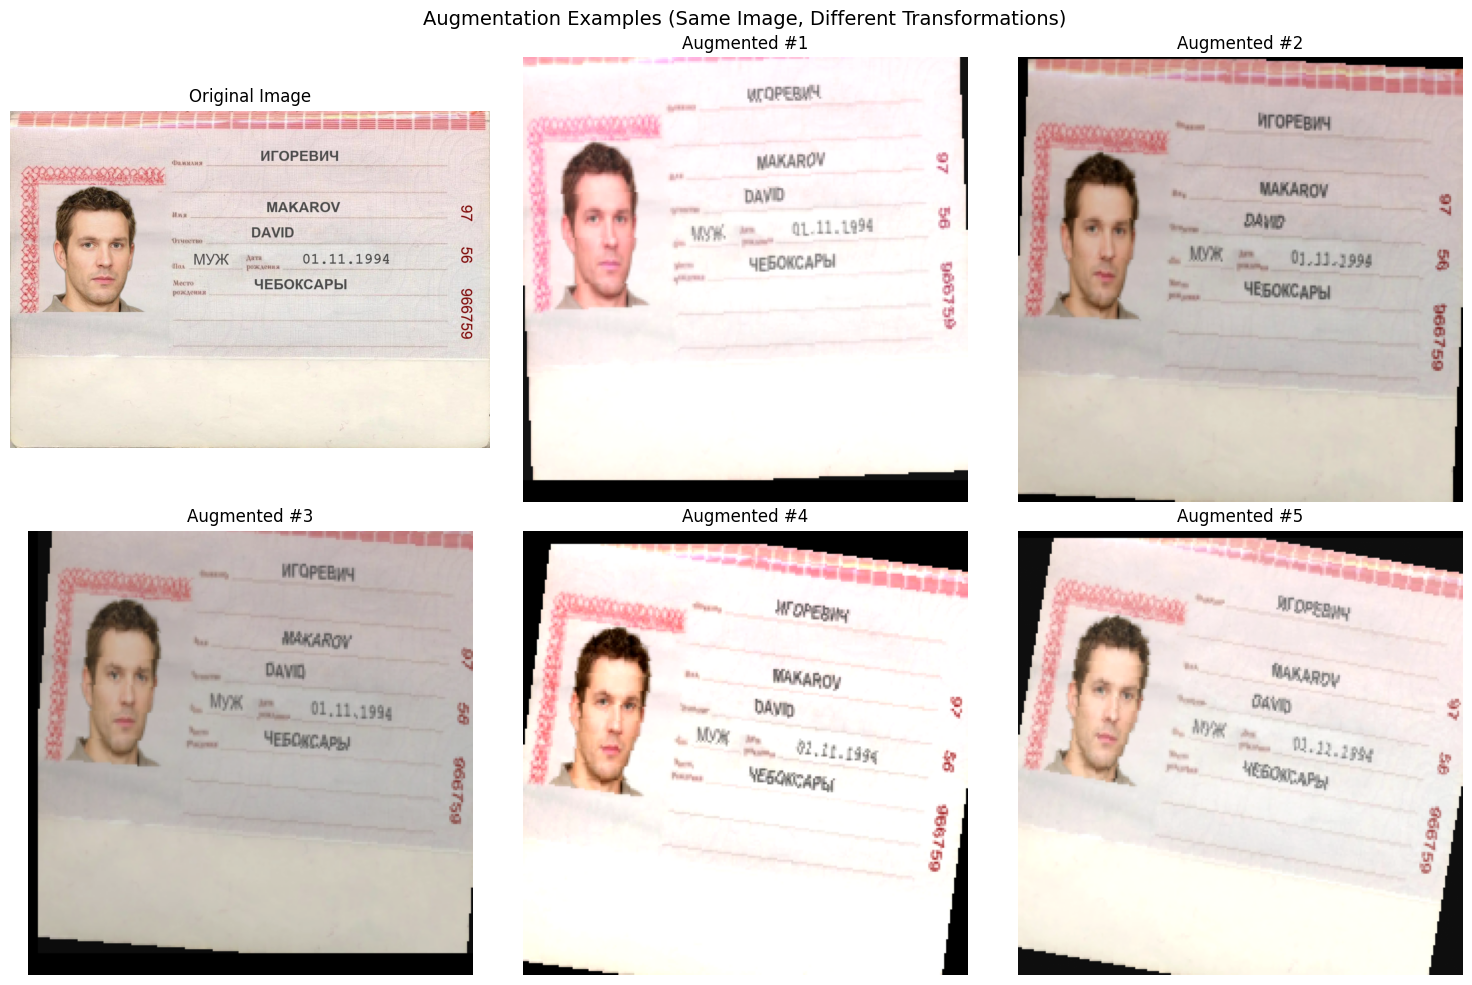

In [47]:
# Show augmentation effects - sample the same image multiple times
sample_idx = 0
sample_path = train_df.iloc[sample_idx]['image_path']
original_image = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Show original
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original Image', fontsize=12)
axes[0, 0].axis('off')

# Show 5 augmented versions
for i in range(5):
    row = (i + 1) // 3
    col = (i + 1) % 3
    
    if row < 2:
        # Apply train transforms (includes augmentation)
        aug_img = train_transforms(original_image)
        # Denormalize for display
        aug_img = denormalize(aug_img.clone())
        aug_img = aug_img.permute(1, 2, 0)
        
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Augmented #{i+1}', fontsize=12)
        axes[row, col].axis('off')

plt.suptitle('Augmentation Examples (Same Image, Different Transformations)', fontsize=14)
plt.tight_layout()
plt.show()


# 10. Save Configuration
# Save preprocessing parameters for use in training notebook

In [49]:
# Save preprocessing configuration for training
# Note: num_workers=0 for notebooks, can be increased in training scripts
config = {
    'image_size': IMG_SIZE[0],  # Using constant
    'batch_size': BATCH_SIZE,   # Using constant
    'num_workers': 0,  # 0 for notebooks, can use 2-4 in training scripts
    'pin_memory': use_pin_memory,
    'normalization': {
        'mean': MEAN,
        'std': STD
    },
    'augmentations': {
        'random_horizontal_flip': False,  # Removed - not suitable for documents
        'random_rotation': 10,
        'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.1, 'hue': 0.05},
        'random_affine': {'translate': (0.05, 0.05)},
        'random_sharpness': {'sharpness_factor': 2, 'p': 0.3}
    },
    'class_mapping': train_dataset.class_to_idx,
    'num_classes': len(train_dataset.classes),
    'dataset_sizes': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset)
    }
}

# Save to file
config_path = Path('../../models/preprocessing_config.json')
config_path.parent.mkdir(parents=True, exist_ok=True)
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Configuration saved to: {config_path}")
print(f"\nConfiguration summary:")
print(f"  Classes: {list(train_dataset.class_to_idx.keys())}")
print(f"  Image size: {config['image_size']}x{config['image_size']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  num_workers: {config['num_workers']} (notebook optimized)")
print(f"  Normalization: Mean={MEAN}, Std={STD}")

# Save class mapping separately for easy loading in training/evaluation
class_mapping_path = Path('../../models/class_mapping.json')
with open(class_mapping_path, 'w') as f:
    json.dump(train_dataset.class_to_idx, f, indent=2)

print(f"\n✓ Class mapping saved to: {class_mapping_path}")
print(f"  {train_dataset.class_to_idx}")


✓ Configuration saved to: ../../models/preprocessing_config.json

Configuration summary:
  Classes: ['driver_license', 'id_card', 'passport']
  Image size: 224x224
  Batch size: 32
  num_workers: 0 (notebook optimized)
  Normalization: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]

✓ Class mapping saved to: ../../models/class_mapping.json
  {'driver_license': 0, 'id_card': 1, 'passport': 2}


# 11. Numerical Summary Statistics
# Detailed statistics for research documentation


In [51]:
# Comprehensive numerical summary for research documentation
print("=" * 70)
print("COMPREHENSIVE DATA PREPROCESSING SUMMARY")
print("=" * 70)

# 1. Dataset sizes per class
print("\n1. SAMPLES PER CLASS:")
print("-" * 70)
for split_name, dataset, df in [("Train", train_dataset, train_df), 
                                 ("Validation", val_dataset, val_df), 
                                 ("Test", test_dataset, test_df)]:
    print(f"\n{split_name} Set:")
    class_counts = df['document_type'].value_counts().sort_index()
    for cls in dataset.classes:
        count = class_counts.get(cls, 0)
        pct = (count / len(df) * 100) if len(df) > 0 else 0
        print(f"  {cls:20} {count:4} samples ({pct:5.1f}%)")

# 2. Augmentation count
print("\n2. DATA AUGMENTATION TECHNIQUES:")
print("-" * 70)
augmentations = [
    "RandomRotation (10°)",
    "ColorJitter (brightness, contrast, saturation, hue)",
    "RandomAffine (translation)",
    "RandomAdjustSharpness"
]
print(f"  Number of augmentation techniques applied: {len(augmentations)}")
for i, aug in enumerate(augmentations, 1):
    print(f"    {i}. {aug}")

# 3. Batch processing time
print("\n3. BATCH PROCESSING PERFORMANCE:")
print("-" * 70)
print("  Measuring time to process one batch...")
start_time = time.time()
sample_batch = next(iter(train_loader))
batch_time = time.time() - start_time
print(f"  Time per batch: {batch_time*1000:.2f} ms")
print(f"  Estimated time per epoch ({len(train_loader)} batches): {batch_time * len(train_loader):.2f} seconds")
print(f"  Estimated samples per second: {BATCH_SIZE / batch_time:.1f}")

# 4. DataLoader configuration
print("\n4. DATALOADER CONFIGURATION:")
print("-" * 70)
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Total samples (train): {len(train_dataset)}")
print(f"  Samples per batch (avg): {len(train_dataset) / len(train_loader):.1f}")

# 5. Image preprocessing
print("\n5. IMAGE PREPROCESSING:")
print("-" * 70)
print(f"  Input image size: {IMG_SIZE[0]}x{IMG_SIZE[1]} pixels")
print(f"  Normalization: ImageNet standard")
print(f"    Mean: {MEAN}")
print(f"    Std: {STD}")

# 6. Error handling
print("\n6. ERROR HANDLING:")
print("-" * 70)
print(f"  Image loading retries: 3 attempts")
print(f"  Error logging: Enabled")

print("\n" + "=" * 70)
print("✓ All statistics computed successfully")
print("=" * 70)


COMPREHENSIVE DATA PREPROCESSING SUMMARY

1. SAMPLES PER CLASS:
----------------------------------------------------------------------

Train Set:
  driver_license        490 samples ( 33.3%)
  id_card               490 samples ( 33.3%)
  passport              490 samples ( 33.3%)

Validation Set:
  driver_license        105 samples ( 33.3%)
  id_card               105 samples ( 33.3%)
  passport              105 samples ( 33.3%)

Test Set:
  driver_license        105 samples ( 33.3%)
  id_card               105 samples ( 33.3%)
  passport              105 samples ( 33.3%)

2. DATA AUGMENTATION TECHNIQUES:
----------------------------------------------------------------------
  Number of augmentation techniques applied: 4
    1. RandomRotation (10°)
    2. ColorJitter (brightness, contrast, saturation, hue)
    3. RandomAffine (translation)
    4. RandomAdjustSharpness

3. BATCH PROCESSING PERFORMANCE:
----------------------------------------------------------------------
  Measuring t

# 12. Summary

In [52]:
# Final summary
print("=" * 60)
print("DATA PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)
print(f"\n✓ Class mapping: {train_dataset.class_to_idx}")
print(f"✓ Number of classes: {len(train_dataset.classes)}")
print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"  Validation: {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"  Test: {len(test_dataset)} samples ({len(test_loader)} batches)")
print(f"\nPreprocessing features:")
print(f"  ✓ Image resize: {IMG_SIZE[0]}x{IMG_SIZE[1]}")
print(f"  ✓ Normalization: Mean={MEAN}, Std={STD}")
print(f"  ✓ Augmentations: Rotation, ColorJitter, Affine, Sharpness (No HorizontalFlip - not suitable for documents)")
print(f"  ✓ Error handling: Enabled (3 retries)")
print(f"\nDataLoader settings (notebook optimized):")
print(f"  ✓ Batch size: {BATCH_SIZE}")
print(f"  ✓ num_workers: 0 (required for notebooks)")
print(f"  ✓ pin_memory: {use_pin_memory} (CUDA only)")
print(f"  ✓ drop_last: True (train only)")
print(f"\nSaved files:")
print(f"  ✓ Configuration: models/preprocessing_config.json")
print(f"  ✓ Class mapping: models/class_mapping.json")
print(f"\nNote: In training scripts, you can increase num_workers to 2-4")
print("\n" + "=" * 60)
print("✓ Data preprocessing and augmentation pipeline ready for training!")
print("=" * 60)

DATA PREPROCESSING PIPELINE SUMMARY

✓ Class mapping: {'driver_license': 0, 'id_card': 1, 'passport': 2}
✓ Number of classes: 3

Dataset sizes:
  Train: 1470 samples (45 batches)
  Validation: 315 samples (10 batches)
  Test: 315 samples (10 batches)

Preprocessing features:
  ✓ Image resize: 224x224
  ✓ Normalization: Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]
  ✓ Augmentations: Rotation, ColorJitter, Affine, Sharpness (No HorizontalFlip - not suitable for documents)
  ✓ Error handling: Enabled (3 retries)

DataLoader settings (notebook optimized):
  ✓ Batch size: 32
  ✓ num_workers: 0 (required for notebooks)
  ✓ pin_memory: False (CUDA only)
  ✓ drop_last: True (train only)

Saved files:
  ✓ Configuration: models/preprocessing_config.json
  ✓ Class mapping: models/class_mapping.json

Note: In training scripts, you can increase num_workers to 2-4

✓ Data preprocessing and augmentation pipeline ready for training!
